In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'LH'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'LH',
 'contract_multiplier': 16,
 'price_tick': 5,
 'margin_rate': 0.08,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00'],
 'light': 1,
 'night': 0,
 'exchange': 'dce',
 'name': '生猪'}

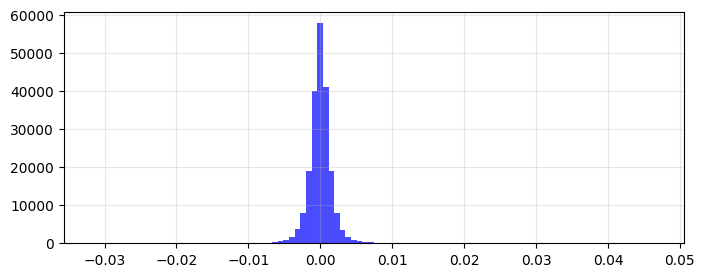

2025-07-01_LH_5


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1885， 筛选之后因子数量：1831

特征重要性过滤： 300 200 	待筛因子个数 1831
无向因子有效个数： 906 有向因子有效个数： 970
  选择有向特征 233 个，重要性范围: 3804.00 - 96.00
  选择无向特征 153 个，重要性范围: 4293.00 - 168.00

单因子sharpe过滤： 0.5 sp范围-16.5718 ~ 12.7591   待筛因子个数 386

特征相关性性过滤： 300     待筛因子个数 336
  选择特征 285 个, 特征最大相关性0.8992491773902551

已挑选日频开盘因子数量： 5 ['day_first4redcorr', 'day_first3power', 'day_jump', 'day_first4greencorr', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_first3power', 'day_jump', 'day_first4greencorr', 'day_first10colarrate']

排除指定因子后，剩余特征 284 个


(207, 0, 51, 26)

正在从 /mnt/Data/writable/liaoyuyang/factor/LH/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (216044, 1889)
训练集时间范围: 2021-02-02 09:11:00 至 2025-06-30 14:49:00
[200]	valid_0's rmse: 0.900046
[400]	valid_0's rmse: 0.899437
[600]	valid_0's rmse: 0.899304
[800]	valid_0's rmse: 0.899248
[1000]	valid_0's rmse: 0.899392
[1200]	valid_0's rmse: 0.899623


<Figure size 1000x600 with 0 Axes>

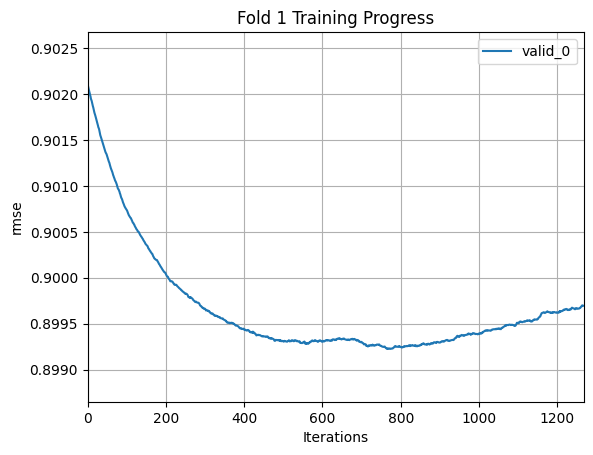

{'train_rmse': np.float64(0.9879093285138255), 'val_rmse': np.float64(0.9965628670959514), 'best_iteration': 768}
test_corr: 0.0314
[200]	valid_0's rmse: 0.98823
[400]	valid_0's rmse: 0.987575
[600]	valid_0's rmse: 0.987228
[800]	valid_0's rmse: 0.987048
[1000]	valid_0's rmse: 0.986978
[1200]	valid_0's rmse: 0.986941
[1400]	valid_0's rmse: 0.986973
[1600]	valid_0's rmse: 0.987013


<Figure size 1000x600 with 0 Axes>

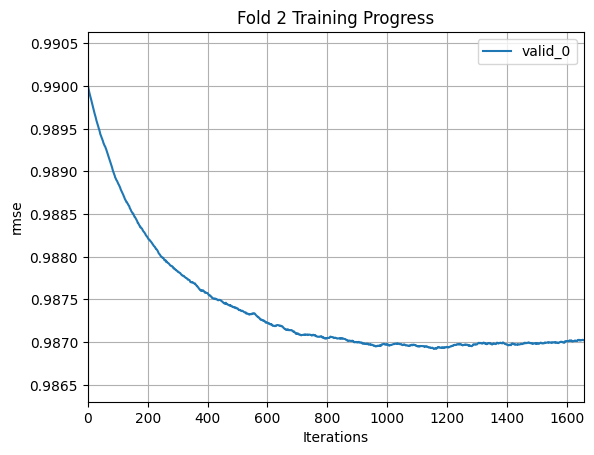

{'train_rmse': np.float64(0.9815646504322098), 'val_rmse': np.float64(0.9969169556420333), 'best_iteration': 1156}
test_corr: 0.0324
[200]	valid_0's rmse: 0.992362
[400]	valid_0's rmse: 0.991438
[600]	valid_0's rmse: 0.990961
[800]	valid_0's rmse: 0.99061
[1000]	valid_0's rmse: 0.990301
[1200]	valid_0's rmse: 0.990079
[1400]	valid_0's rmse: 0.989914
[1600]	valid_0's rmse: 0.989808
[1800]	valid_0's rmse: 0.989713
[2000]	valid_0's rmse: 0.989646
[2200]	valid_0's rmse: 0.98955
[2400]	valid_0's rmse: 0.989511
[2600]	valid_0's rmse: 0.989501
[2800]	valid_0's rmse: 0.989462
[3000]	valid_0's rmse: 0.989449
[3200]	valid_0's rmse: 0.989459


<Figure size 1000x600 with 0 Axes>

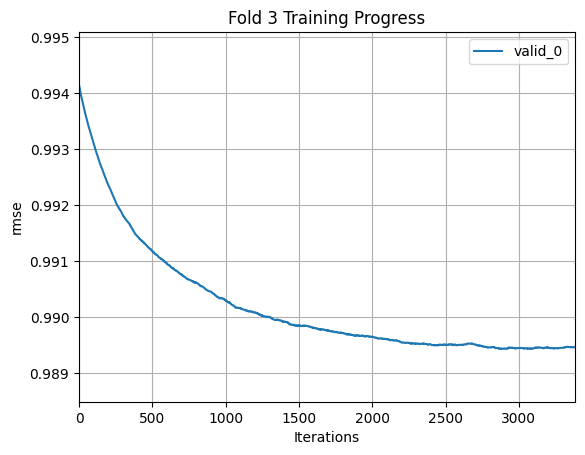

{'train_rmse': np.float64(0.963881539975903), 'val_rmse': np.float64(0.9953336207788009), 'best_iteration': 2883}
test_corr: 0.0448
[200]	valid_0's rmse: 0.993859
[400]	valid_0's rmse: 0.993668
[600]	valid_0's rmse: 0.99362
[800]	valid_0's rmse: 0.993644
[1000]	valid_0's rmse: 0.993681


<Figure size 1000x600 with 0 Axes>

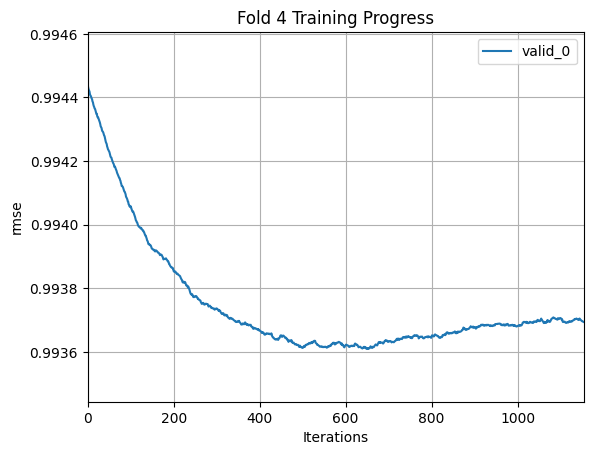

{'train_rmse': np.float64(0.9885663697997098), 'val_rmse': np.float64(0.9991701524580147), 'best_iteration': 654}
test_corr: 0.0329
[200]	valid_0's rmse: 0.994039
[400]	valid_0's rmse: 0.993905
[600]	valid_0's rmse: 0.993847
[800]	valid_0's rmse: 0.993802
[1000]	valid_0's rmse: 0.993747
[1200]	valid_0's rmse: 0.993682
[1400]	valid_0's rmse: 0.993656
[1600]	valid_0's rmse: 0.99361
[1800]	valid_0's rmse: 0.993592
[2000]	valid_0's rmse: 0.993574
[2200]	valid_0's rmse: 0.993568
[2400]	valid_0's rmse: 0.993566
[2600]	valid_0's rmse: 0.993568
[2800]	valid_0's rmse: 0.993533
[3000]	valid_0's rmse: 0.993528
[3200]	valid_0's rmse: 0.993514
[3400]	valid_0's rmse: 0.993563
[3600]	valid_0's rmse: 0.993579


<Figure size 1000x600 with 0 Axes>

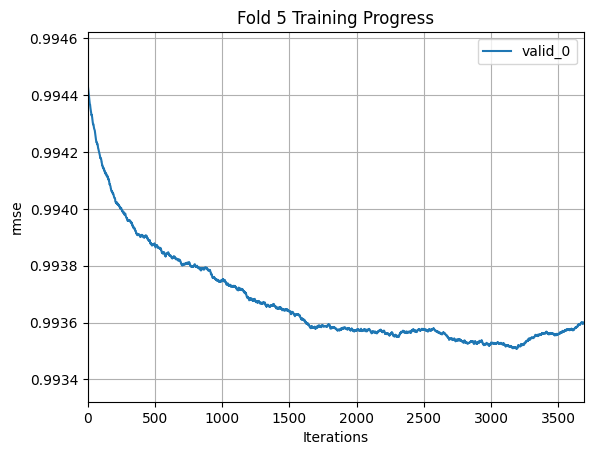

{'train_rmse': np.float64(0.9623827555736938), 'val_rmse': np.float64(0.9990354338692885), 'best_iteration': 3190}
test_corr: 0.0315


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/LH_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-02 09:01:00,lh2109,25715.0,25750.0,25705.0,25750.0,25724.419643,25723.103251,109.0,44858720.0,...,13.258929,133,2021-02-02,25726.50,25730.800000,25726.851852,25723.697917,-0.000948,-0.002280,-0.002648
1,2021-02-02 09:02:00,lh2109,25750.0,25770.0,25750.0,25765.0,25763.195876,25763.075165,81.0,33389840.0,...,8.814433,117,2021-02-02,25754.75,25754.722222,25758.235294,25764.367816,-0.000240,-0.001899,-0.002061
2,2021-02-02 09:03:00,lh2109,25770.0,25770.0,25715.0,25730.0,25741.296296,25742.076880,62.0,25542240.0,...,11.481481,111,2021-02-02,25763.00,25759.000000,25760.714286,25739.933333,-0.000128,-0.001106,-0.001543
3,2021-02-02 09:04:00,lh2109,25730.0,25740.0,25725.0,25730.0,25733.362069,25733.956207,42.0,17293120.0,...,7.327586,70,2021-02-02,25730.75,25730.357143,25731.071429,25733.750000,-0.000406,-0.000643,-0.001260
4,2021-02-02 09:05:00,lh2109,25730.0,25740.0,25725.0,25725.0,25730.300000,25730.693548,40.0,16467840.0,...,6.600000,63,2021-02-02,25732.75,25732.272727,25733.000000,25730.454545,-0.000559,-0.000285,-0.000778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275295,2026-03-06 14:56:00,lh2605,11160.0,11165.0,11160.0,11160.0,11160.414634,11160.084520,446.0,79640880.0,...,5.243902,205,2026-03-06,11160.50,11160.238095,11160.131579,11160.409836,-0.000061,0.010200,0.015614
275296,2026-03-06 14:57:00,lh2605,11160.0,11165.0,11160.0,11165.0,11162.672414,11161.191529,224.0,40005520.0,...,5.000000,174,2026-03-06,11160.25,11161.447368,11162.413793,11162.947020,0.000084,0.010566,0.017665
275297,2026-03-06 14:58:00,lh2605,11165.0,11165.0,11160.0,11160.0,11162.255814,11161.643826,267.0,47686240.0,...,5.000000,215,2026-03-06,11162.50,11162.750000,11163.333333,11162.265625,0.000087,0.010008,0.014871
275298,2026-03-06 14:59:00,lh2605,11160.0,11170.0,11160.0,11165.0,11163.333333,11162.692292,641.0,114500800.0,...,5.000000,222,2026-03-06,11164.00,11163.095238,11161.842105,11163.207071,0.007891,0.010949,0.015517


In [10]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00']


  0%|          | 0/32609 [00:00<?, ?it/s]

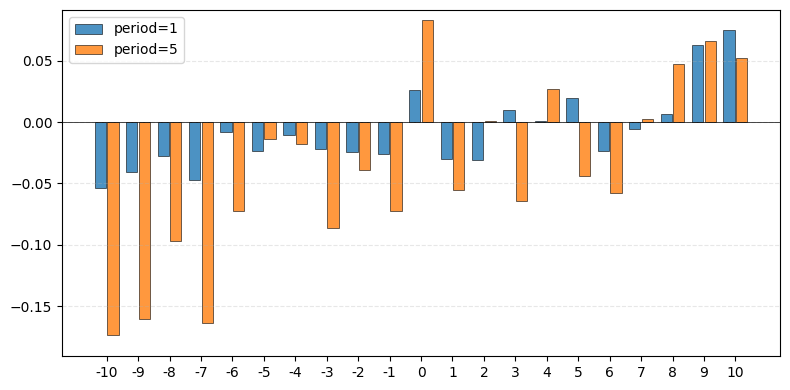

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,6960
空头(-1) 数量,6753
空仓(0) 数量,18898
多头占比,21.34%
空头占比,20.71%
空仓占比,57.95%
交易日数量,145
总收益(非年化%),21.44
总交易次数（开平算一次）,1383
日均交易次数（开平算一次）,9.54


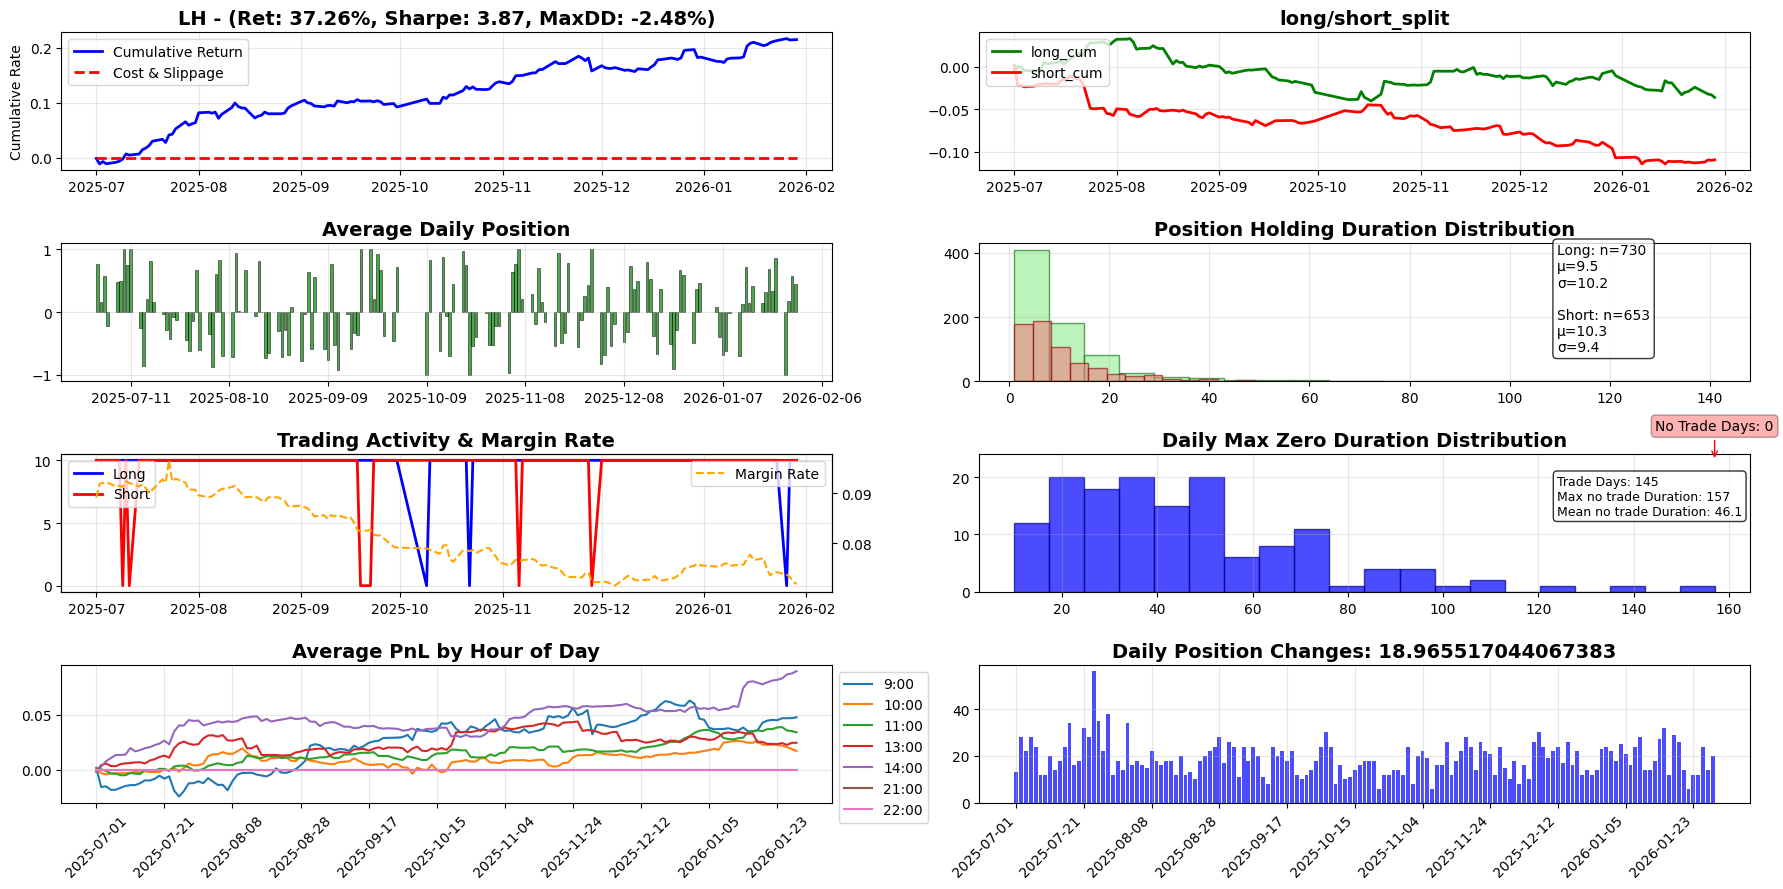

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: LH
📅 总交易日数: 145
📊 总数据点: 35090
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)